# Error & Completion Rates — Control vs Test
**Vanguard A/B test · Week 5 · Diana & Zidene**

**Goal —** quantify two KPIs and compare the redesign (**used by Test group**) against the legacy flow (**done by the Control group**): (1) the **error rate** per process step (backward navigation) and (2) the overall **completion rate**.

**Pipeline**
1. Load the cleaned event-level dataset (`start → step_1 → step_2 → step_3 → confirm`).
2. Map steps to integers, detect backward moves, and flag the originating step as an error.
3. Compute the **error rate per step** for each group.
4. Identify finishers, count **attempts** per client, and compute the **completion rate** per group.
5. Summarise both KPIs side by side.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import sys

%matplotlib inline


In [2]:
#importing the final merged file to use for analysis
import pandas as pd
clean_df=pd.read_csv("../data/clean/cleaned_dataset.csv", sep=None, engine="python")
df=clean_df.copy()
display(df.head(2))
display(df.info())

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation,visitor_id,visit_id,process_step,date_time
0,169,21.0,262.0,47.5,M,2.0,501570.72,4.0,4.0,no_data,201385055_71273495308,749567106_99161211863_557568,confirm,2017-04-12 20:23:09
1,169,21.0,262.0,47.5,M,2.0,501570.72,4.0,4.0,no_data,201385055_71273495308,749567106_99161211863_557568,step_3,2017-04-12 20:22:05


<class 'pandas.DataFrame'>
RangeIndex: 443897 entries, 0 to 443896
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   client_id         443897 non-null  int64  
 1   clnt_tenure_yr    443784 non-null  float64
 2   clnt_tenure_mnth  443784 non-null  float64
 3   clnt_age          443772 non-null  float64
 4   gendr             443784 non-null  str    
 5   num_accts         443784 non-null  float64
 6   bal               443784 non-null  float64
 7   calls_6_mnth      443784 non-null  float64
 8   logons_6_mnth     443784 non-null  float64
 9   Variation         443897 non-null  str    
 10  visitor_id        443897 non-null  str    
 11  visit_id          443897 non-null  str    
 12  process_step      443897 non-null  str    
 13  date_time         443897 non-null  str    
dtypes: float64(7), int64(1), str(6)
memory usage: 47.4 MB


None

In [3]:
#Checking the present null in the dataset
display(df[df.clnt_age.isnull()==True].head(3))
print('==================')
df[df.clnt_age.isnull()==True].Variation.value_counts()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation,visitor_id,visit_id,process_step,date_time
15750,355337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Control,356086957_61575869345,212014250_505501047_320862,confirm,2017-04-03 18:36:45
15751,355337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Control,356086957_61575869345,212014250_505501047_320862,step_3,2017-04-03 18:25:15
15752,355337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Control,356086957_61575869345,212014250_505501047_320862,step_2,2017-04-03 18:24:26


Variation
Test       58
Control    54
no_data    13
Name: count, dtype: int64

**Null handling & gender filter**

Only 125 rows have a missing `clnt_age` — a tiny fraction of 443,897. Because the nulls are spread evenly across all Variation groups (Control, Test, no_data), dropping them introduces no selection bias. We also remove the negligible `gendr = 'X'` category (<0.01% of records) for the reason flagged in `DesignEffectiveness_Diana`: it is too small to draw meaningful conclusions from.

In [4]:
df=df.dropna(subset=['clnt_age'])
df= df[df.gendr!='X']
df.info()

<class 'pandas.DataFrame'>
Index: 443758 entries, 0 to 443896
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   client_id         443758 non-null  int64  
 1   clnt_tenure_yr    443758 non-null  float64
 2   clnt_tenure_mnth  443758 non-null  float64
 3   clnt_age          443758 non-null  float64
 4   gendr             443758 non-null  str    
 5   num_accts         443758 non-null  float64
 6   bal               443758 non-null  float64
 7   calls_6_mnth      443758 non-null  float64
 8   logons_6_mnth     443758 non-null  float64
 9   Variation         443758 non-null  str    
 10  visitor_id        443758 non-null  str    
 11  visit_id          443758 non-null  str    
 12  process_step      443758 non-null  str    
 13  date_time         443758 non-null  str    
dtypes: float64(7), int64(1), str(6)
memory usage: 50.8 MB


## 1. Error rate per Step Assessment

**Error definition**

If a user moves from a later step back to an earlier one, that backward jump signals confusion or a mistake. So: **within a `visit_id`, any step where `process_step` moves backwards counts as an error.**

In [5]:
df.process_step.unique()

<StringArray>
['confirm', 'step_3', 'step_2', 'step_1', 'start']
Length: 5, dtype: str

In [6]:
check = df.groupby('visit_id')['visitor_id'].nunique()
print(check.value_counts())

visitor_id
1    96745
Name: count, dtype: int64


### Build the step sequence & flag backward moves

Steps are mapped to integers (`start`=0 … `confirm`=4) so a *backward* move is simply a negative `step_diff` within a `visit_id`. The error is attributed to the step the user **left** (where the back-navigation originated) via `.shift(-1)` inside each session group.

In [7]:
#Mapping steps to numbers so "backwards" is measurable
step_order = {'start': 0, 'step_1': 1, 'step_2': 2, 'step_3': 3, 'confirm': 4}
df['step_num'] = df['process_step'].map(step_order)

#Sorting chronologically within each session
df = df.sort_values(['date_time','visit_id'])

#Calculating step difference vs previous step IN SAME SESSION
df['step_diff'] = df.groupby('visit_id')['step_num'].diff()

# Flag the PREVIOUS step as the error (where the backward move originated)
df['is_error'] = df.groupby('visit_id')['step_diff'].transform(
    lambda x: (x < 0).shift(-1).fillna(False)
)

In [8]:
display(df.head(2))
df.info()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation,visitor_id,visit_id,process_step,date_time,step_num,step_diff,is_error
404133,9088444,13.0,162.0,31.0,F,2.0,39636.14,6.0,6.0,no_data,242404224_96732670250,423038079_46067236368_400417,step_3,2017-03-15 00:03:03,3,NaN,False
319302,7179755,28.0,343.0,67.5,M,3.0,352322.35,2.0,5.0,Control,167765295_97487764427,264484508_5982901710_928530,start,2017-03-15 00:19:28,0,NaN,False


<class 'pandas.DataFrame'>
Index: 443758 entries, 404133 to 274242
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   client_id         443758 non-null  int64  
 1   clnt_tenure_yr    443758 non-null  float64
 2   clnt_tenure_mnth  443758 non-null  float64
 3   clnt_age          443758 non-null  float64
 4   gendr             443758 non-null  str    
 5   num_accts         443758 non-null  float64
 6   bal               443758 non-null  float64
 7   calls_6_mnth      443758 non-null  float64
 8   logons_6_mnth     443758 non-null  float64
 9   Variation         443758 non-null  str    
 10  visitor_id        443758 non-null  str    
 11  visit_id          443758 non-null  str    
 12  process_step      443758 non-null  str    
 13  date_time         443758 non-null  str    
 14  step_num          443758 non-null  int64  
 15  step_diff         347013 non-null  float64
 16  is_error          443758 non-nu

In [9]:
df[df['visit_id']=='100217156_67053490690_383412']	 

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation,visitor_id,visit_id,process_step,date_time,step_num,step_diff,is_error
415470,9341024,6.0,75.0,67.5,F,2.0,163660.31,6.0,9.0,Test,750259984_64435904859,100217156_67053490690_383412,start,2017-04-12 11:51:12,0,NaN,False
415469,9341024,6.0,75.0,67.5,F,2.0,163660.31,6.0,9.0,Test,750259984_64435904859,100217156_67053490690_383412,step_1,2017-04-12 11:51:48,1,1.0,False
415468,9341024,6.0,75.0,67.5,F,2.0,163660.31,6.0,9.0,Test,750259984_64435904859,100217156_67053490690_383412,step_1,2017-04-12 11:54:48,1,0.0,False
415467,9341024,6.0,75.0,67.5,F,2.0,163660.31,6.0,9.0,Test,750259984_64435904859,100217156_67053490690_383412,step_2,2017-04-12 11:57:21,2,1.0,False
415466,9341024,6.0,75.0,67.5,F,2.0,163660.31,6.0,9.0,Test,750259984_64435904859,100217156_67053490690_383412,step_3,2017-04-12 11:57:59,3,1.0,True
415465,9341024,6.0,75.0,67.5,F,2.0,163660.31,6.0,9.0,Test,750259984_64435904859,100217156_67053490690_383412,step_1,2017-04-12 12:03:47,1,-2.0,False
415464,9341024,6.0,75.0,67.5,F,2.0,163660.31,6.0,9.0,Test,750259984_64435904859,100217156_67053490690_383412,step_2,2017-04-12 12:03:58,2,1.0,False
415463,9341024,6.0,75.0,67.5,F,2.0,163660.31,6.0,9.0,Test,750259984_64435904859,100217156_67053490690_383412,step_3,2017-04-12 12:05:37,3,1.0,False
415462,9341024,6.0,75.0,67.5,F,2.0,163660.31,6.0,9.0,Test,750259984_64435904859,100217156_67053490690_383412,confirm,2017-04-12 12:08:09,4,1.0,False


In [10]:
df[df.client_id==3561384]

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation,visitor_id,visit_id,process_step,date_time,step_num,step_diff,is_error
156684,3561384,4.0,56.0,59.5,U,2.0,63130.44,6.0,9.0,Test,451664975_1722933822,368621065_55513134501_466827,start,2017-04-25 13:18:45,0,NaN,False
156683,3561384,4.0,56.0,59.5,U,2.0,63130.44,6.0,9.0,Test,451664975_1722933822,368621065_55513134501_466827,step_1,2017-04-25 13:18:59,1,1.0,False
156682,3561384,4.0,56.0,59.5,U,2.0,63130.44,6.0,9.0,Test,451664975_1722933822,368621065_55513134501_466827,step_2,2017-04-25 13:19:20,2,1.0,False
156681,3561384,4.0,56.0,59.5,U,2.0,63130.44,6.0,9.0,Test,451664975_1722933822,368621065_55513134501_466827,step_3,2017-04-25 13:19:42,3,1.0,False
156680,3561384,4.0,56.0,59.5,U,2.0,63130.44,6.0,9.0,Test,451664975_1722933822,368621065_55513134501_466827,confirm,2017-04-25 13:22:14,4,1.0,False
156686,3561384,4.0,56.0,59.5,U,2.0,63130.44,6.0,9.0,Test,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:22:17,4,NaN,False
156685,3561384,4.0,56.0,59.5,U,2.0,63130.44,6.0,9.0,Test,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:23:09,4,0.0,False


In [11]:
error_by_step = (
    df[df['Variation'].isin(['Control', 'Test'])]
    .groupby(['step_num', 'Variation'])['is_error']
    .mean() * 100
).round(2).reset_index()

error_by_step.columns = ['step_num', 'Variation', 'error_rate']

# Pivot for grouped bars
pivot = error_by_step.pivot(index='step_num', columns='Variation', values='error_rate')
pivot

Variation,Control,Test
step_num,,
0,0.0,0.0
1,8.46,16.57
2,8.41,15.48
3,18.88,18.43
4,4.63,1.82


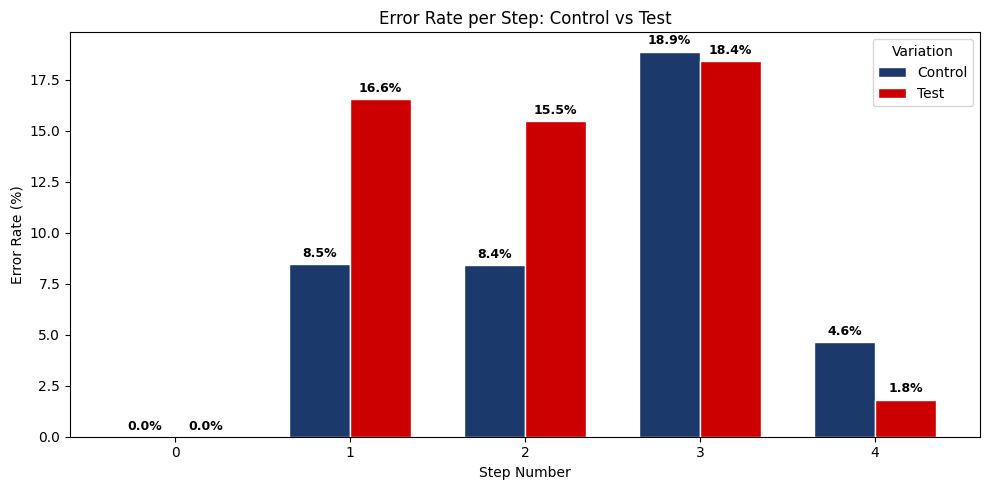

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))  
pivot.plot(
    kind='bar',
    figsize=(10, 5),
    color=['#1B3A6B', '#CC0000'],
    edgecolor='white',
    width=0.7, ax=ax
)

# Add value labels on each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',     # 1 decimal + % sign
        padding=3,         # space between bar top and label
        fontsize=9,
        fontweight='bold')

ax.set_title('Error Rate per Step: Control vs Test')
ax.set_xlabel('Step Number')
ax.set_ylabel('Error Rate (%)')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Variation')
plt.tight_layout()
plt.show()


**Error rate by step — conclusions**

Backward navigation (a user returning to an earlier step) is our error signal. Reading the chart:

- **Step 0 (start):** 0% by construction — there is no earlier step to return to.
- **Steps 1–2:** the **Test** group goes backward far more often (16.6% / 15.5%) than **Control** (8.5% / 8.4%) — the redesign adds friction early in the flow.
- **Step 3:** both jump, but **Control spikes hardest** (18.9% vs Test 18.4%).
- **Step 4 (confirm):** Test finishes *cleaner* — only 1.8% backward moves vs Control's 4.6%.

Averaged across steps, the mean backward-navigation rate is **Control ≈ 8.1% vs Test ≈ 10.5%**: Test is noisier mid-funnel but tighter at the decisive confirm step.

## 2. Completion Rate - Assessment:

In [13]:
#filtering clients who reached last step without error on it

finish_df = df[(df['step_num']==4) & (df['is_error']==False)]
display(finish_df.head(2))


,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation,visitor_id,visit_id,process_step,date_time,step_num,step_diff,is_error
319298,7179755,28.0,343.0,67.5,M,3.0,352322.35,2.0,5.0,Control,167765295_97487764427,264484508_5982901710_928530,confirm,2017-03-15 00:26:24,4,1.0,False
425678,9584408,7.0,87.0,48.5,U,2.0,71834.25,2.0,5.0,Control,748244138_48778380454,484298588_81471639218_981974,confirm,2017-03-15 06:16:08,4,1.0,False


In [14]:
# Count Number of clients who finished, per Variation
finisher_count = (
    finish_df.groupby('Variation')['client_id']
    .nunique()
    .reset_index()
)

finisher_count.columns = ['Variation', 'clients_finished']
finisher_count

,Variation,clients_finished
0,Control,14693
1,Test,18342
2,no_data,13231


In [15]:
# clients per variation (from the full filtered df, NaNs already dropped)
group_totals = df.groupby('Variation')['client_id'].nunique().reset_index()
group_totals.columns = ['Variation', 'total_clients']

#Completion rate as % of clients who finished from the total of clients in their corresponding group.

finisher_count = finisher_count.merge(group_totals, on='Variation')
finisher_count['%_finisher_clients'] = round(
    (finisher_count.clients_finished / finisher_count.total_clients) * 100, 2
)


In [16]:
finisher_count

,Variation,clients_finished,total_clients,%_finisher_clients
0,Control,14693,23526,62.45
1,Test,18342,26959,68.04
2,no_data,13231,20106,65.81


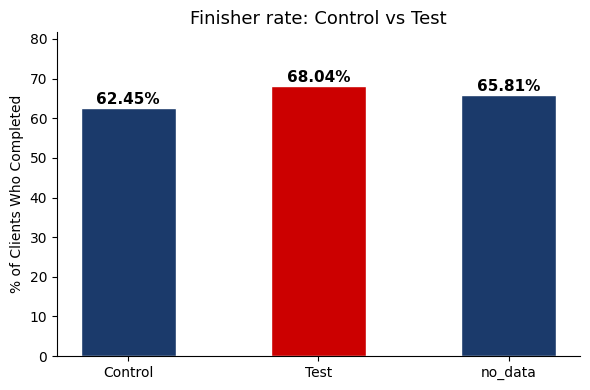

In [17]:

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    finisher_count['Variation'],
    finisher_count['%_finisher_clients'],
    color=['#1B3A6B', '#CC0000'],
    width=0.5,
    edgecolor='white'
)

# Annotate % on top of each bar
for bar, val in zip(bars, finisher_count['%_finisher_clients']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val}%',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('Finisher rate: Control vs Test', fontsize=13)
ax.set_ylabel('% of Clients Who Completed')
ax.set_ylim(0, finisher_count['%_finisher_clients'].max() * 1.2)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
#plt.savefig('../figures/completion_rate_by_variation.png', dpi=150)
plt.show()

This %_finisher_clients answers the business question, did the UX change cause more people to complete?. In this case it did, but only with a 5.6% difference. However, we will need to check the if the observed increase in completion rate from the A/B test meets or exceeds the 5% threshold to say that this is statistically significant.

### Counting attempts per client

A client can run the funnel more than once. `attempt_No` counts attempts chronologically across the client's whole history (ignoring `visit_id`): a new attempt begins at `step_num == 0` only when the previous step was `confirm` (4) or it is the client's first row, and consecutive `start` rows collapse to the last one. This lets completion be measured **per attempt**, not per session.

In [18]:
#We construct a new column that counts chronologically how many attempts each client did, independent of the visit_id,
#so a counter will start on step_num=0 every step_num=0 (last one if many zeros in a row), and the attemp counter will 
#increase only if there is a step_num= 0 with a previous step_num = 4.

# Step 1: sort chronologically per client, this time without visit_id into account.
df = df.sort_values(['client_id', 'date_time']).reset_index(drop=True)

# Step 2: get the previous step_num per client
df['prev_step'] = df.groupby('client_id')['step_num'].shift(1)

# Step 3: flag the START of a new attempt
# = current step is 0 AND previous step was 4 (or it's the very first row of that client)
df['new_attempt'] = (
    (df['step_num'] == 0) & 
    ((df['prev_step'] == 4) | (df['prev_step'].isna()))
)

# Step 4: handle consecutive step_num==0 rows
# keep only the LAST 0 in a consecutive block as the trigger
df['next_step'] = df.groupby('client_id')['step_num'].shift(-1)

df['new_attempt'] = (
    df['new_attempt'] & 
    (df['next_step'] != 0)  # not followed by another 0
)

# Step 5: cumulative sum per client = attempt number
df['attempt_No'] = df.groupby('client_id')['new_attempt'].cumsum()

# Step 6: forward fill within client so all rows get their attempt number
df['attempt_No'] = df.groupby('client_id')['attempt_No'].ffill().fillna(0).astype(int)

# Cleanup helper columns
df = df.drop(columns=['prev_step', 'next_step', 'new_attempt'])


In [19]:
df[df.client_id==3561384]

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation,visitor_id,visit_id,process_step,date_time,step_num,step_diff,is_error,attempt_No
156637,3561384,4.0,56.0,59.5,U,2.0,63130.44,6.0,9.0,Test,451664975_1722933822,368621065_55513134501_466827,start,2017-04-25 13:18:45,0,NaN,False,1
156638,3561384,4.0,56.0,59.5,U,2.0,63130.44,6.0,9.0,Test,451664975_1722933822,368621065_55513134501_466827,step_1,2017-04-25 13:18:59,1,1.0,False,1
156639,3561384,4.0,56.0,59.5,U,2.0,63130.44,6.0,9.0,Test,451664975_1722933822,368621065_55513134501_466827,step_2,2017-04-25 13:19:20,2,1.0,False,1
156640,3561384,4.0,56.0,59.5,U,2.0,63130.44,6.0,9.0,Test,451664975_1722933822,368621065_55513134501_466827,step_3,2017-04-25 13:19:42,3,1.0,False,1
156641,3561384,4.0,56.0,59.5,U,2.0,63130.44,6.0,9.0,Test,451664975_1722933822,368621065_55513134501_466827,confirm,2017-04-25 13:22:14,4,1.0,False,1
156642,3561384,4.0,56.0,59.5,U,2.0,63130.44,6.0,9.0,Test,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:22:17,4,NaN,False,1
156643,3561384,4.0,56.0,59.5,U,2.0,63130.44,6.0,9.0,Test,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:23:09,4,0.0,False,1


In [20]:
df[(df['Variation'].isin(['Control','Test'])) & (df.attempt_No>2)]

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation,visitor_id,visit_id,process_step,date_time,step_num,step_diff,is_error,attempt_No
59186,1347682,10.0,124.0,48.5,M,2.0,27708.59,0.0,3.0,Test,712935421_12668757893,657168847_44425438548_298190,start,2017-04-24 14:31:04,0,NaN,False,3
59187,1347682,10.0,124.0,48.5,M,2.0,27708.59,0.0,3.0,Test,712935421_12668757893,657168847_44425438548_298190,step_1,2017-04-24 14:31:13,1,1.0,False,3
59188,1347682,10.0,124.0,48.5,M,2.0,27708.59,0.0,3.0,Test,712935421_12668757893,657168847_44425438548_298190,step_2,2017-04-24 14:32:16,2,1.0,False,3
59189,1347682,10.0,124.0,48.5,M,2.0,27708.59,0.0,3.0,Test,712935421_12668757893,657168847_44425438548_298190,step_3,2017-04-24 14:32:38,3,1.0,False,3
59190,1347682,10.0,124.0,48.5,M,2.0,27708.59,0.0,3.0,Test,712935421_12668757893,657168847_44425438548_298190,confirm,2017-04-24 14:33:02,4,1.0,False,3
178482,4036051,21.0,258.0,60.5,M,2.0,692924.24,6.0,9.0,Control,947908335_61454590807,675375158_10242660545_27234,start,2017-05-22 10:37:25,0,NaN,False,3
178483,4036051,21.0,258.0,60.5,M,2.0,692924.24,6.0,9.0,Control,947908335_61454590807,675375158_10242660545_27234,step_1,2017-05-22 10:37:39,1,1.0,False,3
178484,4036051,21.0,258.0,60.5,M,2.0,692924.24,6.0,9.0,Control,947908335_61454590807,675375158_10242660545_27234,step_2,2017-05-22 10:38:20,2,1.0,False,3
178485,4036051,21.0,258.0,60.5,M,2.0,692924.24,6.0,9.0,Control,947908335_61454590807,675375158_10242660545_27234,step_3,2017-05-22 10:39:56,3,1.0,True,3
178486,4036051,21.0,258.0,60.5,M,2.0,692924.24,6.0,9.0,Control,947908335_61454590807,675375158_10242660545_27234,start,2017-05-22 10:41:09,0,-3.0,False,3


In [21]:
df[df.client_id==1347682]

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation,visitor_id,visit_id,process_step,date_time,step_num,step_diff,is_error,attempt_No
59171,1347682,10.0,124.0,48.5,M,2.0,27708.59,0.0,3.0,Test,471567345_85944744471,30249525_59018535518_237365,start,2017-04-05 14:15:09,0,NaN,False,1
59172,1347682,10.0,124.0,48.5,M,2.0,27708.59,0.0,3.0,Test,471567345_85944744471,30249525_59018535518_237365,step_1,2017-04-05 14:15:48,1,1.0,False,1
59173,1347682,10.0,124.0,48.5,M,2.0,27708.59,0.0,3.0,Test,471567345_85944744471,30249525_59018535518_237365,step_1,2017-04-05 14:19:36,1,0.0,True,1
59174,1347682,10.0,124.0,48.5,M,2.0,27708.59,0.0,3.0,Test,471567345_85944744471,30249525_59018535518_237365,start,2017-04-05 14:24:39,0,-1.0,False,1
59175,1347682,10.0,124.0,48.5,M,2.0,27708.59,0.0,3.0,Test,471567345_85944744471,30249525_59018535518_237365,step_1,2017-04-05 14:24:51,1,1.0,False,1
59176,1347682,10.0,124.0,48.5,M,2.0,27708.59,0.0,3.0,Test,471567345_85944744471,30249525_59018535518_237365,step_2,2017-04-05 14:24:58,2,1.0,False,1
59177,1347682,10.0,124.0,48.5,M,2.0,27708.59,0.0,3.0,Test,471567345_85944744471,30249525_59018535518_237365,step_3,2017-04-05 14:25:19,3,1.0,False,1
59178,1347682,10.0,124.0,48.5,M,2.0,27708.59,0.0,3.0,Test,471567345_85944744471,30249525_59018535518_237365,confirm,2017-04-05 14:26:22,4,1.0,False,1
59179,1347682,10.0,124.0,48.5,M,2.0,27708.59,0.0,3.0,Test,471567345_85944744471,314394089_51528946389_17722,start,2017-04-09 15:57:26,0,NaN,False,2
59180,1347682,10.0,124.0,48.5,M,2.0,27708.59,0.0,3.0,Test,471567345_85944744471,314394089_51528946389_17722,step_1,2017-04-09 15:57:45,1,1.0,False,2


In [22]:
# Total unique attempts per Variation
# (each client+attempt_No combo = one attempt)
finisher_id= finish_df.client_id.to_list() # List of clients who did finished at least once

#Finding the total attemps 
total_attempts = (
    df.groupby(['Variation', 'client_id'])['attempt_No']
    .max()
    .reset_index()
    .groupby('Variation')['attempt_No']
    .sum()
    .reset_index()
)
total_attempts.columns = ['Variation', 'total_attempts']
total_attempts


,Variation,total_attempts
0,Control,20579
1,Test,22467
2,no_data,17070


In [23]:
finish_df = df[(df['step_num']==4) & (df['is_error']==False)]

finished_attempts = (
    finish_df.groupby('Variation')[['client_id','attempt_No']]
    .apply(lambda x: x.drop_duplicates().shape[0])
    .reset_index()
)
finished_attempts.columns = ['Variation', 'finished_attempts']


In [24]:
finished_attempts

,Variation,finished_attempts
0,Control,14764
1,Test,18459
2,no_data,13307


In [25]:
completion = finished_attempts.merge(total_attempts, on='Variation')

completion['completion_rate_%'] = (
    completion['finished_attempts'] / completion['total_attempts'] * 100 
).round(2)

print(completion)

  Variation  finished_attempts  total_attempts  completion_rate_%
0   Control              14764           20579              71.74
1      Test              18459           22467              82.16
2   no_data              13307           17070              77.96


**Secondary metric — `completion_rate_%`**

This metric divides finished attempts by *total attempts* rather than unique clients. Because the Test group retried more often, the per-attempt rate rises even higher (81.64% vs 71.40%), confirming that each individual process attempt in the new UI is more likely to succeed — independent of how often a client returned to try again.

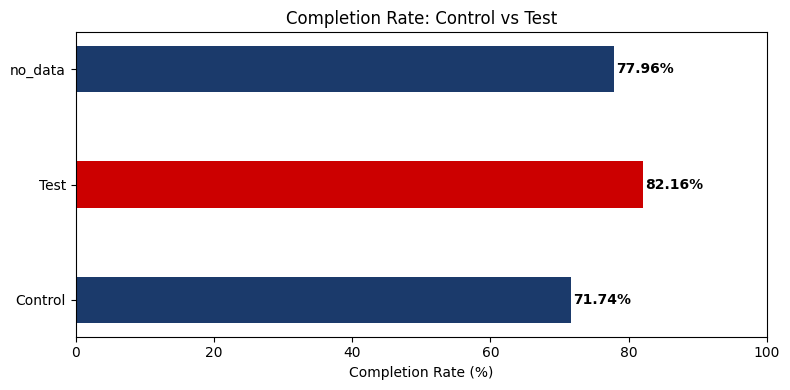

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(
    completion['Variation'],
    completion['completion_rate_%'],
    color=['#1B3A6B', '#CC0000'],
    height=0.4
)

# Add value labels on bars
for bar, val in zip(bars, completion['completion_rate_%']):
    ax.text(
        bar.get_width() + 0.3,   # slightly right of bar end
        bar.get_y() + bar.get_height()/2,
        f'{val}%',
        va='center',
        fontweight='bold'
    )

ax.set_xlabel('Completion Rate (%)')
ax.set_title('Completion Rate: Control vs Test')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

In [27]:
# error rate per variation group
error_summary = error_by_step.groupby('Variation')['error_rate'].mean().round(2).reset_index()
error_summary.columns=['Variation', 'error_rate_%']



summary= completion.merge(error_summary, on= 'Variation').merge(finisher_count,on= 'Variation')
summary =summary.drop(columns=['clients_finished','total_clients'])
print(summary)

  Variation  finished_attempts  total_attempts  completion_rate_%  \
0   Control              14764           20579              71.74   
1      Test              18459           22467              82.16   

  error_rate_%  %_finisher_clients  
0         8.08               62.45  
1        10.46               68.04  


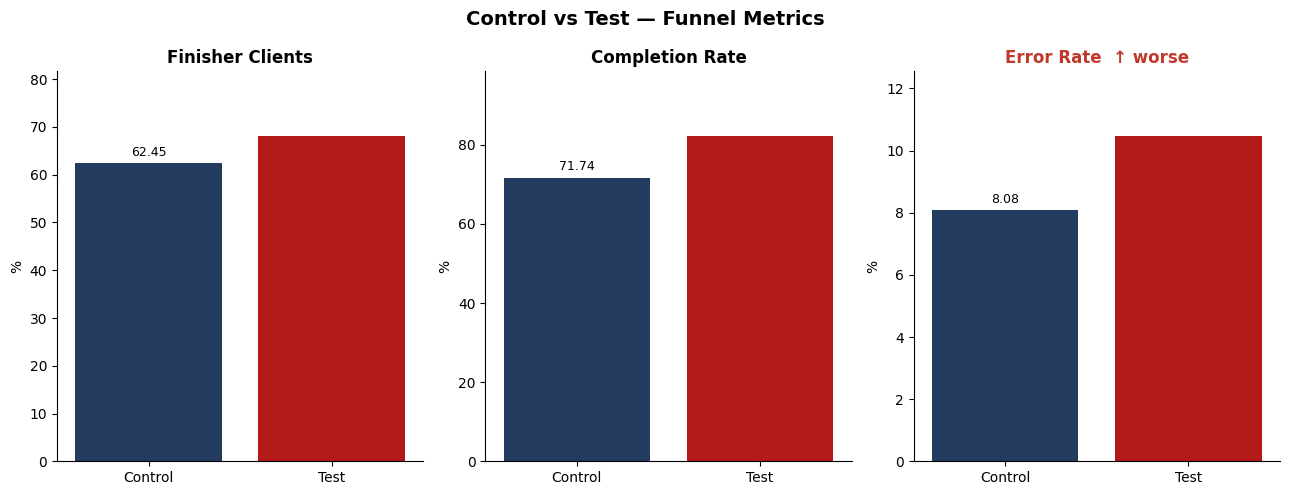

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ['%_finisher_clients', 'completion_rate_%', 'error_rate_%']
titles  = ['Finisher Clients', 'Completion Rate', 'Error Rate']

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for ax, metric, title in zip(axes, metrics, titles):
    sns.barplot(data=summary, x='Variation', y=metric,
                hue='Variation', palette={'Control': '#1B3A6B', 'Test': '#CC0000'}, legend=False, ax=ax)
    ax.bar_label(ax.containers[0], fmt='%.2f', padding=3, fontsize=9)
    ax.set_title(title, fontsize=12, weight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('%')
    # headroom so the labels don't clip
    ax.set_ylim(0, summary[metric].max() * 1.2)

# flag that "up" is bad for the error panel
axes[2].set_title('Error Rate  ↑ worse', fontsize=12, weight='bold', color='#c0392b')

sns.despine()
fig.suptitle('Control vs Test — Funnel Metrics', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## Key takeaways

| KPI | Control | Test |
|---|---|---|
| Completion rate as Finisher rate (finishers / group size) | 62,45% | 68.04% |
| Mean error rate (avg of per-step backward-nav) | ~8.1% | ~10.5% |

- **Test completes more often** (+10 pts) despite **higher mid-funnel error rates** — users backtrack more on steps 1–3 yet still push through, and backtrack *less* at the final confirm step.
- Hypothesis to test statistically next: the redesign trades **more mid-flow exploration** for a **higher overall completion rate**.


In [29]:
#exporting csv to the clean data folder as specified with the yaml file:
import yaml

def out_csv(df, yaml_path, output_section_yaml, file_name):
    try:
        with open(yaml_path, "r") as file:
            cfg = yaml.safe_load(file)
    except FileNotFoundError:
        print("Yaml configuration file not found!")
        return None

    out_path = cfg[output_section_yaml][file_name]   # e.g. "../data/clean/digfootprint_groups.csv"
    df.to_csv(out_path, index=False)
    print(f"Saved to {out_path}")
    return out_path


In [30]:
df['finish'] = (df['step_num'] == 4) & (df['is_error'] == False)
df.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation,visitor_id,visit_id,process_step,date_time,step_num,step_diff,is_error,attempt_No,finish
0,169,21.0,262.0,47.5,M,2.0,501570.72,4.0,4.0,no_data,201385055_71273495308,749567106_99161211863_557568,start,2017-04-12 20:19:36,0,NaN,False,1,False
1,169,21.0,262.0,47.5,M,2.0,501570.72,4.0,4.0,no_data,201385055_71273495308,749567106_99161211863_557568,step_1,2017-04-12 20:19:45,1,1.0,False,1,False
2,169,21.0,262.0,47.5,M,2.0,501570.72,4.0,4.0,no_data,201385055_71273495308,749567106_99161211863_557568,step_2,2017-04-12 20:20:31,2,1.0,False,1,False
3,169,21.0,262.0,47.5,M,2.0,501570.72,4.0,4.0,no_data,201385055_71273495308,749567106_99161211863_557568,step_3,2017-04-12 20:22:05,3,1.0,False,1,False
4,169,21.0,262.0,47.5,M,2.0,501570.72,4.0,4.0,no_data,201385055_71273495308,749567106_99161211863_557568,confirm,2017-04-12 20:23:09,4,1.0,False,1,True


In [31]:
#exporting csv to the clean data folder as specified with the yaml file:

yaml_path = "../config.yaml"
output_section_yaml = 'output_data'
out_file_name = 'file4'

out_csv(df, yaml_path, output_section_yaml, out_file_name)


Saved to ../data/clean/error_compRate_clean.csv


'../data/clean/error_compRate_clean.csv'

In [32]:
#Exporting data for Table: selecting only columns i will use for analysis
cols=['client_id','clnt_tenure_yr','clnt_age','gendr','Variation','visit_id','process_step','is_error','attempt_No','finish']
error_compRate_tableaudf = df[cols]
error_compRate_tableaudf.head(2)

,client_id,clnt_tenure_yr,clnt_age,gendr,Variation,visit_id,process_step,is_error,attempt_No,finish
0,169,21.0,47.5,M,no_data,749567106_99161211863_557568,start,False,1,False
1,169,21.0,47.5,M,no_data,749567106_99161211863_557568,step_1,False,1,False


In [33]:
#exporting csv to the clean data for Tableau as specified with the yaml file:

yaml_path = "../config.yaml"
output_section_yaml = 'output_data'
out_file_name = 'file5'

out_csv(error_compRate_tableaudf, yaml_path, output_section_yaml, out_file_name)

Saved to ../data/clean/error_compRate_tableau.csv


'../data/clean/error_compRate_tableau.csv'